# Pose Classifier — Model Evaluation

Evaluates `pose_classifier_best.pt` on the held-out **test** split.

Sections: Setup · Inference · Performance · Report · Confusion Matrix · Sample Results · Misclassified Examples · Confidence Distribution · Mean Skeleton Visualisation

## Setup

In [1]:
import os
import json
import warnings
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from collections import Counter
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
)
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.dpi': 130,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.family': 'DejaVu Sans',
})

print('Libraries loaded ')

Libraries loaded 


## Config

In [2]:
DATA_ROOT   = '../keypoints_json'
CHECKPOINT  = 'weights/pose_classifier_best.pt'
BATCH_SIZE  = 64
DEVICE      = 'mps' if torch.backends.mps.is_available() else 'cpu'

CLASS_MAP = {
    'spike':   0,
    'defense': 1,
    'block':   2,
    'set':     3,
    'serve':   4,
}
IDX_TO_CLASS = {v: k for k, v in CLASS_MAP.items()}
CLASS_NAMES  = [IDX_TO_CLASS[i] for i in range(len(CLASS_MAP))]
CLASS_COLORS = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12', '#9b59b6']

# COCO skeleton connectivity
SKELETON = [
    (0, 1), (0, 2), (1, 3), (2, 4),
    (5, 6), (5, 7), (7, 9), (6, 8), (8, 10),
    (5, 11), (6, 12), (11, 12),
    (11, 13), (13, 15), (12, 14), (14, 16),
]
KP_NAMES = [
    'nose', 'left_eye', 'right_eye', 'left_ear', 'right_ear',
    'left_shoulder', 'right_shoulder', 'left_elbow', 'right_elbow',
    'left_wrist', 'right_wrist', 'left_hip', 'right_hip',
    'left_knee', 'right_knee', 'left_ankle', 'right_ankle',
]

print(f'Device   : {DEVICE}')
print(f'Checkpoint: {CHECKPOINT}')
print(f'Classes  : {CLASS_NAMES}')

Device   : mps
Checkpoint: weights/pose_classifier_best.pt
Classes  : ['spike', 'defense', 'block', 'set', 'serve']


## Feature Engineering

Must match `train.py` exactly.

In [3]:
def get_angle(a, b, c):
    ba = a - b
    bc = c - b
    cos_angle = np.dot(ba, bc) / (np.linalg.norm(ba) * np.linalg.norm(bc) + 1e-6)
    return np.arccos(np.clip(cos_angle, -1.0, 1.0))


def normalize_keypoints(kp):
    kp   = np.array(kp)
    xy   = kp[:, :2].copy()
    conf = kp[:, 2:]

    xy[conf.squeeze() < 0.3] = 0

    center = (xy[11] + xy[12]) / 2
    xy -= center

    torso = np.linalg.norm((xy[5] + xy[6]) / 2)
    if torso > 0:
        xy /= torso

    if xy[6][0] < xy[5][0]:
        xy[:, 0] *= -1

    angles = [
        get_angle(xy[5],  xy[7],  xy[9]),   # left elbow
        get_angle(xy[6],  xy[8],  xy[10]),  # right elbow
        get_angle(xy[11], xy[13], xy[15]),  # left knee
        get_angle(xy[12], xy[14], xy[16]),  # right knee
        get_angle(xy[7],  xy[5],  xy[11]),  # left shoulder
        get_angle(xy[8],  xy[6],  xy[12]),  # right shoulder
    ]

    return np.concatenate([xy.flatten(), conf.flatten(), np.array(angles)])


print('Feature engineering functions defined ')

Feature engineering functions defined 


## Dataset & Model

In [4]:
class PoseDataset(Dataset):
    def __init__(self, split):
        self.samples = []
        split_dir = os.path.join(DATA_ROOT, split)

        for class_name in CLASS_MAP:
            class_dir = os.path.join(split_dir, class_name)
            if not os.path.exists(class_dir):
                continue
            for file in os.listdir(class_dir):
                if file.endswith('.json'):
                    self.samples.append((
                        os.path.join(class_dir, file),
                        CLASS_MAP[class_name],
                    ))

        counts = Counter(s[1] for s in self.samples)
        print(f'{split} split — {len(self.samples)} samples')
        for i, name in IDX_TO_CLASS.items():
            print(f'  {name}: {counts.get(i, 0)}')

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        with open(path) as f:
            data = json.load(f)
        kp = normalize_keypoints(data['keypoints'])
        return torch.tensor(kp, dtype=torch.float32), torch.tensor(label), path


class PoseClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(57, 256), nn.BatchNorm1d(256), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(256, 256), nn.BatchNorm1d(256), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(256, 128), nn.BatchNorm1d(128), nn.ReLU(), nn.Dropout(0.2),
            nn.Linear(128, 5),
        )

    def forward(self, x):
        return self.net(x)

## Load Checkpoint & Run Inference

In [5]:
test_dataset = PoseDataset('test')
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

model = PoseClassifier().to(DEVICE)
model.load_state_dict(torch.load(CHECKPOINT, map_location=DEVICE))
model.eval()
print(f'Loaded {CHECKPOINT} ')

all_preds  = []
all_labels = []
all_probs  = []
all_paths  = []
all_feats  = []

with torch.no_grad():
    for x, y, paths in test_loader:
        x      = x.to(DEVICE)
        logits = model(x)
        probs  = torch.softmax(logits, dim=1)
        preds  = probs.argmax(dim=1)

        all_feats.extend(x.cpu().numpy())
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(y.numpy())
        all_probs.extend(probs.cpu().numpy())
        all_paths.extend(paths)

all_feats  = np.array(all_feats)
all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)
all_probs  = np.array(all_probs)

print(f'\nInference complete on {len(all_labels)} samples ')

test split — 885 samples
  spike: 273
  defense: 17
  block: 284
  set: 189
  serve: 122
Loaded weights/pose_classifier_best.pt 

Inference complete on 885 samples 


## Model Performance (Accuracy, Precision, Recall, F1-Score)

  Test Accuracy  : 62.82%
  Precision      : 64.91%
  Recall         : 62.82%
  F1-Score       : 62.64%


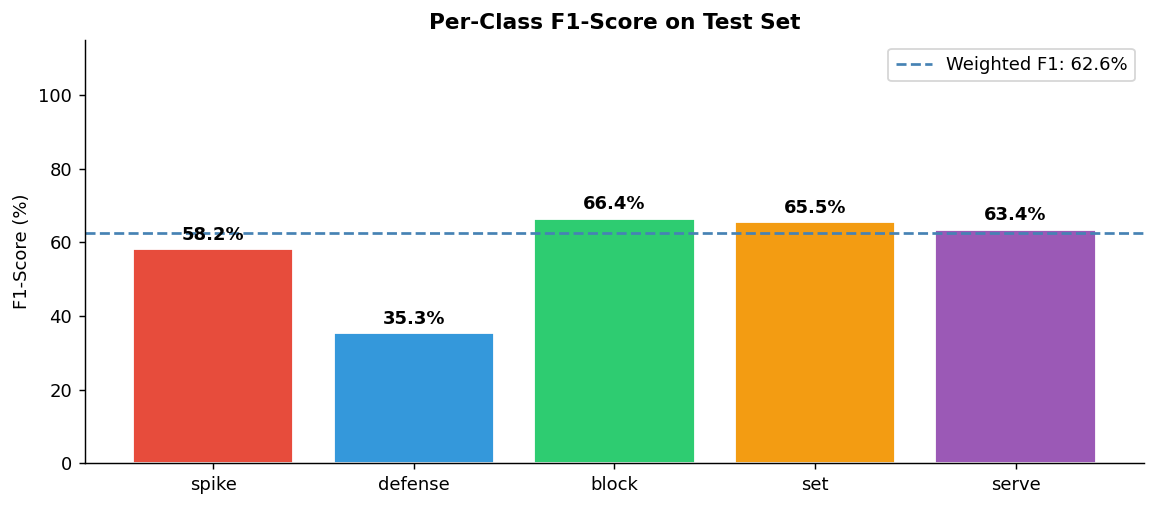

Saved → per_class_f1.png


In [6]:
accuracy  = accuracy_score(all_labels, all_preds)
precision = precision_score(all_labels, all_preds, average='weighted', zero_division=0)
recall    = recall_score(all_labels, all_preds, average='weighted', zero_division=0)
f1        = f1_score(all_labels, all_preds, average='weighted', zero_division=0)

print('=' * 45)
print(f'  Test Accuracy  : {accuracy  * 100:.2f}%')
print(f'  Precision      : {precision * 100:.2f}%')
print(f'  Recall         : {recall    * 100:.2f}%')
print(f'  F1-Score       : {f1        * 100:.2f}%')
print('=' * 45)

# Per-class F1 bar chart
per_class_f1 = f1_score(all_labels, all_preds, average=None, zero_division=0)

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(CLASS_NAMES, per_class_f1 * 100, color=CLASS_COLORS, edgecolor='white')
ax.set_ylim(0, 115)
ax.set_ylabel('F1-Score (%)')
ax.set_title('Per-Class F1-Score on Test Set', fontweight='bold')
ax.axhline(f1 * 100, color='steelblue', linestyle='--', linewidth=1.5,
           label=f'Weighted F1: {f1*100:.1f}%')
ax.legend()

for bar, val in zip(bars, per_class_f1):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1.5,
            f'{val*100:.1f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('visuals/per_class_f1.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → per_class_f1.png')

## Per-Class Classification Report

In [7]:
print(classification_report(
    all_labels, all_preds,
    target_names=CLASS_NAMES,
    digits=4,
    zero_division=0,
))

              precision    recall  f1-score   support

       spike     0.6780    0.5092    0.5816       273
     defense     0.3529    0.3529    0.3529        17
       block     0.7403    0.6021    0.6641       284
         set     0.5737    0.7619    0.6545       189
       serve     0.5304    0.7869    0.6337       122

    accuracy                         0.6282       885
   macro avg     0.5751    0.6026    0.5774       885
weighted avg     0.6491    0.6282    0.6264       885



## Confusion Matrix + Normalized

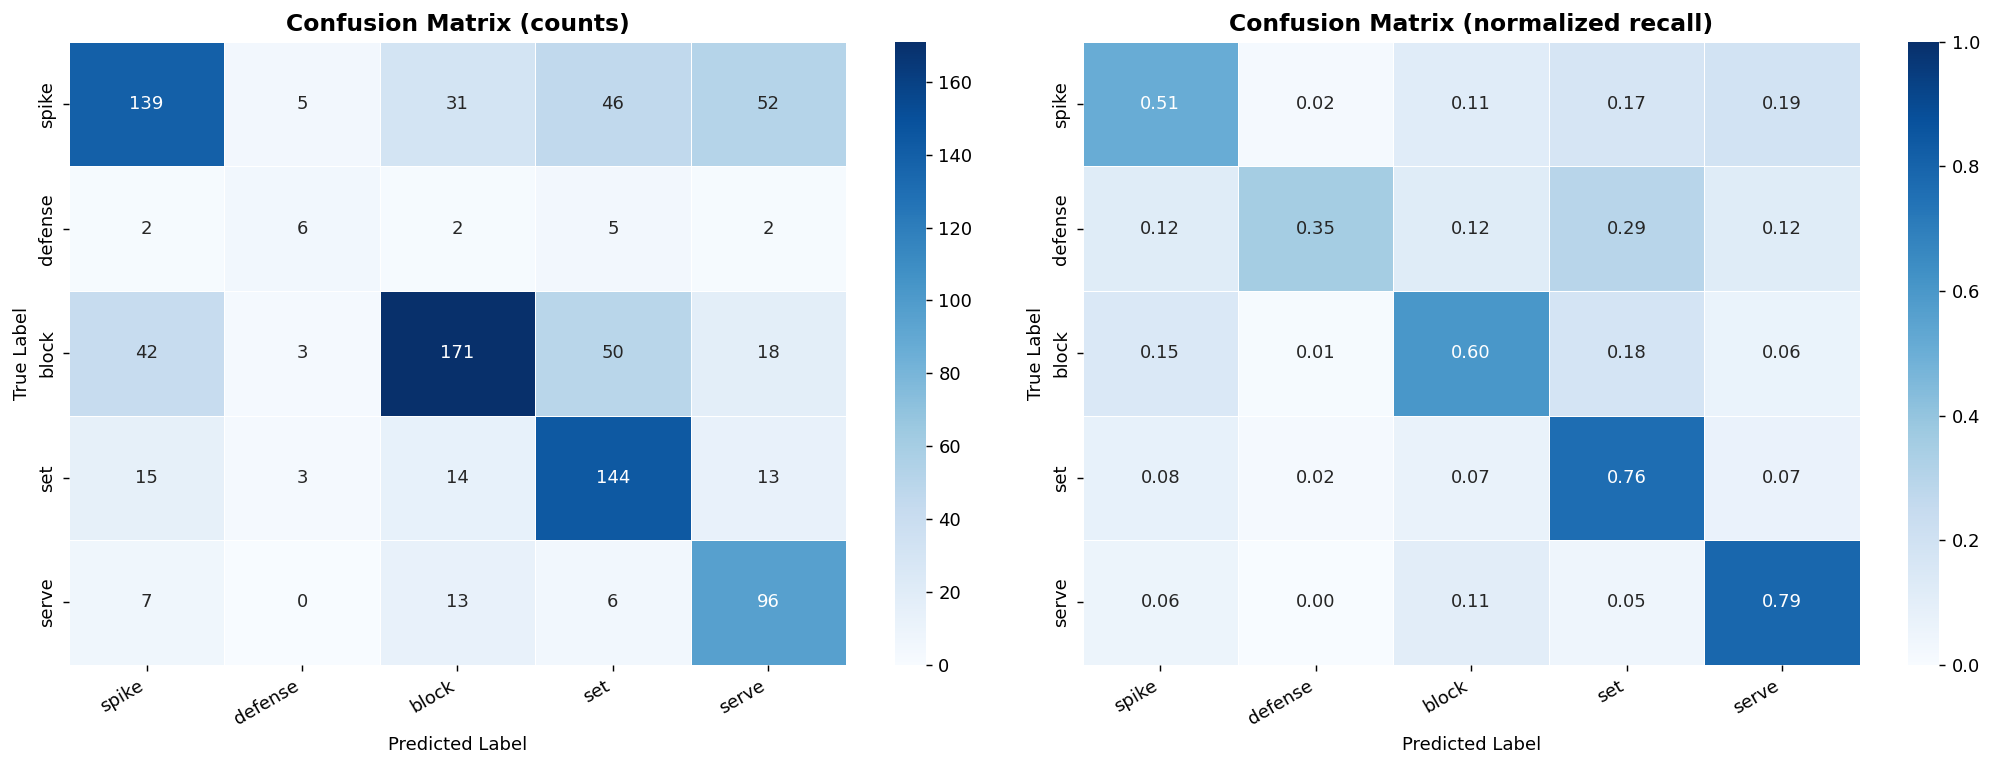

Saved → confusion_matrix.png


In [8]:
cm      = confusion_matrix(all_labels, all_preds)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
    linewidths=0.5, ax=axes[0],
)
axes[0].set_title('Confusion Matrix (counts)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Predicted Label')
axes[0].set_ylabel('True Label')
axes[0].set_xticklabels(CLASS_NAMES, rotation=30, ha='right')

sns.heatmap(
    cm_norm, annot=True, fmt='.2f', cmap='Blues',
    xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
    vmin=0, vmax=1, linewidths=0.5, ax=axes[1],
)
axes[1].set_title('Confusion Matrix (normalized recall)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Predicted Label')
axes[1].set_ylabel('True Label')
axes[1].set_xticklabels(CLASS_NAMES, rotation=30, ha='right')

plt.tight_layout()
plt.savefig('visuals/confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → confusion_matrix.png')

## Sample Classification Results with Confidence Scores

Displays one sample per class (correct & incorrect), drawn as a skeleton with the predicted label and confidence score annotated.

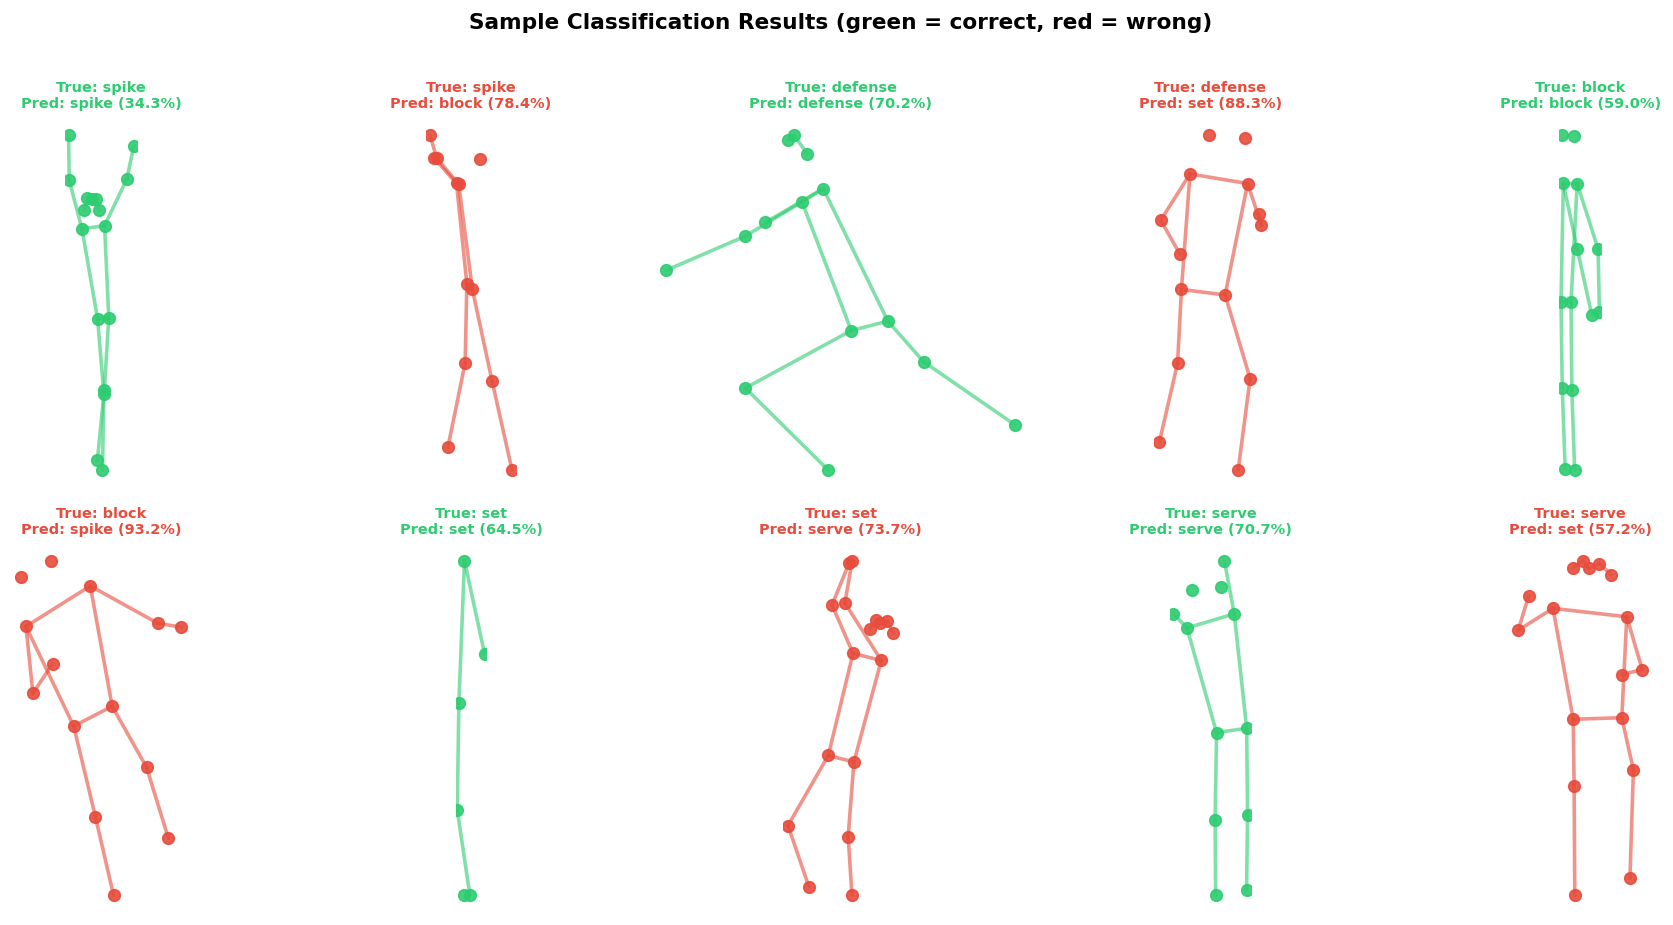

Saved → sample_results.png


In [9]:
def load_raw_kp(path):
    with open(path) as f:
        return np.array(json.load(f)['keypoints'])


def draw_skeleton_ax(ax, kp_raw, title, color):
    """Draw a COCO skeleton from raw keypoints on ax."""
    xy   = kp_raw[:, :2].copy()
    conf = kp_raw[:, 2]
    xy[conf < 0.3] = np.nan

    for (i, j) in SKELETON:
        xs = [xy[i, 0], xy[j, 0]]
        ys = [xy[i, 1], xy[j, 1]]
        if np.any(np.isnan(xs)) or np.any(np.isnan(ys)):
            continue
        ax.plot(xs, ys, '-', color=color, lw=2, alpha=0.6)

    valid = conf >= 0.3
    ax.scatter(xy[valid, 0], xy[valid, 1], s=40, c=color, zorder=5, alpha=0.9)

    ax.set_aspect('equal')
    ax.invert_yaxis()
    ax.set_title(title, fontsize=8, color=color, fontweight='bold')
    ax.axis('off')


# Collect 2 samples per class: one correct, one incorrect (if available)
np.random.seed(42)
display_items = []   # (path, true_idx, pred_idx, confidence)

for cls_idx in range(len(CLASS_NAMES)):
    cls_mask     = all_labels == cls_idx
    correct_mask = cls_mask & (all_preds == all_labels)
    wrong_mask   = cls_mask & (all_preds != all_labels)

    for mask in [correct_mask, wrong_mask]:
        idxs = np.where(mask)[0]
        if len(idxs) == 0:
            continue
        pick = np.random.choice(idxs)
        display_items.append((
            all_paths[pick],
            all_labels[pick],
            all_preds[pick],
            all_probs[pick][all_preds[pick]],
        ))

n    = len(display_items)
cols = 5
rows = (n + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(cols * 3, rows * 3.5))
axes = axes.flatten()

for ax, (path, true_idx, pred_idx, conf) in zip(axes, display_items):
    kp_raw  = load_raw_kp(path)
    correct = (true_idx == pred_idx)
    color   = '#2ecc71' if correct else '#e74c3c'
    title   = (
        f'True: {CLASS_NAMES[true_idx]}\n'
        f'Pred: {CLASS_NAMES[pred_idx]} ({conf*100:.1f}%)'
    )
    draw_skeleton_ax(ax, kp_raw, title, color)
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_edgecolor(color)
        spine.set_linewidth(2)

for ax in axes[n:]:
    ax.axis('off')

plt.suptitle('Sample Classification Results (green = correct, red = wrong)',
             fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('visuals/sample_results.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → sample_results.png')

## Misclassified Examples

Sorted by prediction confidence descending — the most confidently wrong predictions first.

In [10]:
wrong_idx   = np.where(all_labels != all_preds)[0]
wrong_confs = all_probs[wrong_idx, all_preds[wrong_idx]]
sorted_wrong = wrong_idx[np.argsort(-wrong_confs)]  # most confident first
display_idx = sorted_wrong[:16]

print(f'Total misclassified: {len(wrong_idx)} / {len(all_labels)} '
      f'({len(wrong_idx)/len(all_labels)*100:.1f}%)')

from collections import Counter as _Counter
pairs = _Counter(
    (CLASS_NAMES[all_labels[i]], CLASS_NAMES[all_preds[i]])
    for i in wrong_idx
)
print('\nTop misclassification pairs (True → Predicted):')
for (true_c, pred_c), count in pairs.most_common(10):
    print(f'  {true_c:>12} → {pred_c:<12}  ({count} samples)')

Total misclassified: 329 / 885 (37.2%)

Top misclassification pairs (True → Predicted):
         spike → serve         (52 samples)
         block → set           (50 samples)
         spike → set           (46 samples)
         block → spike         (42 samples)
         spike → block         (31 samples)
         block → serve         (18 samples)
           set → spike         (15 samples)
           set → block         (14 samples)
           set → serve         (13 samples)
         serve → block         (13 samples)


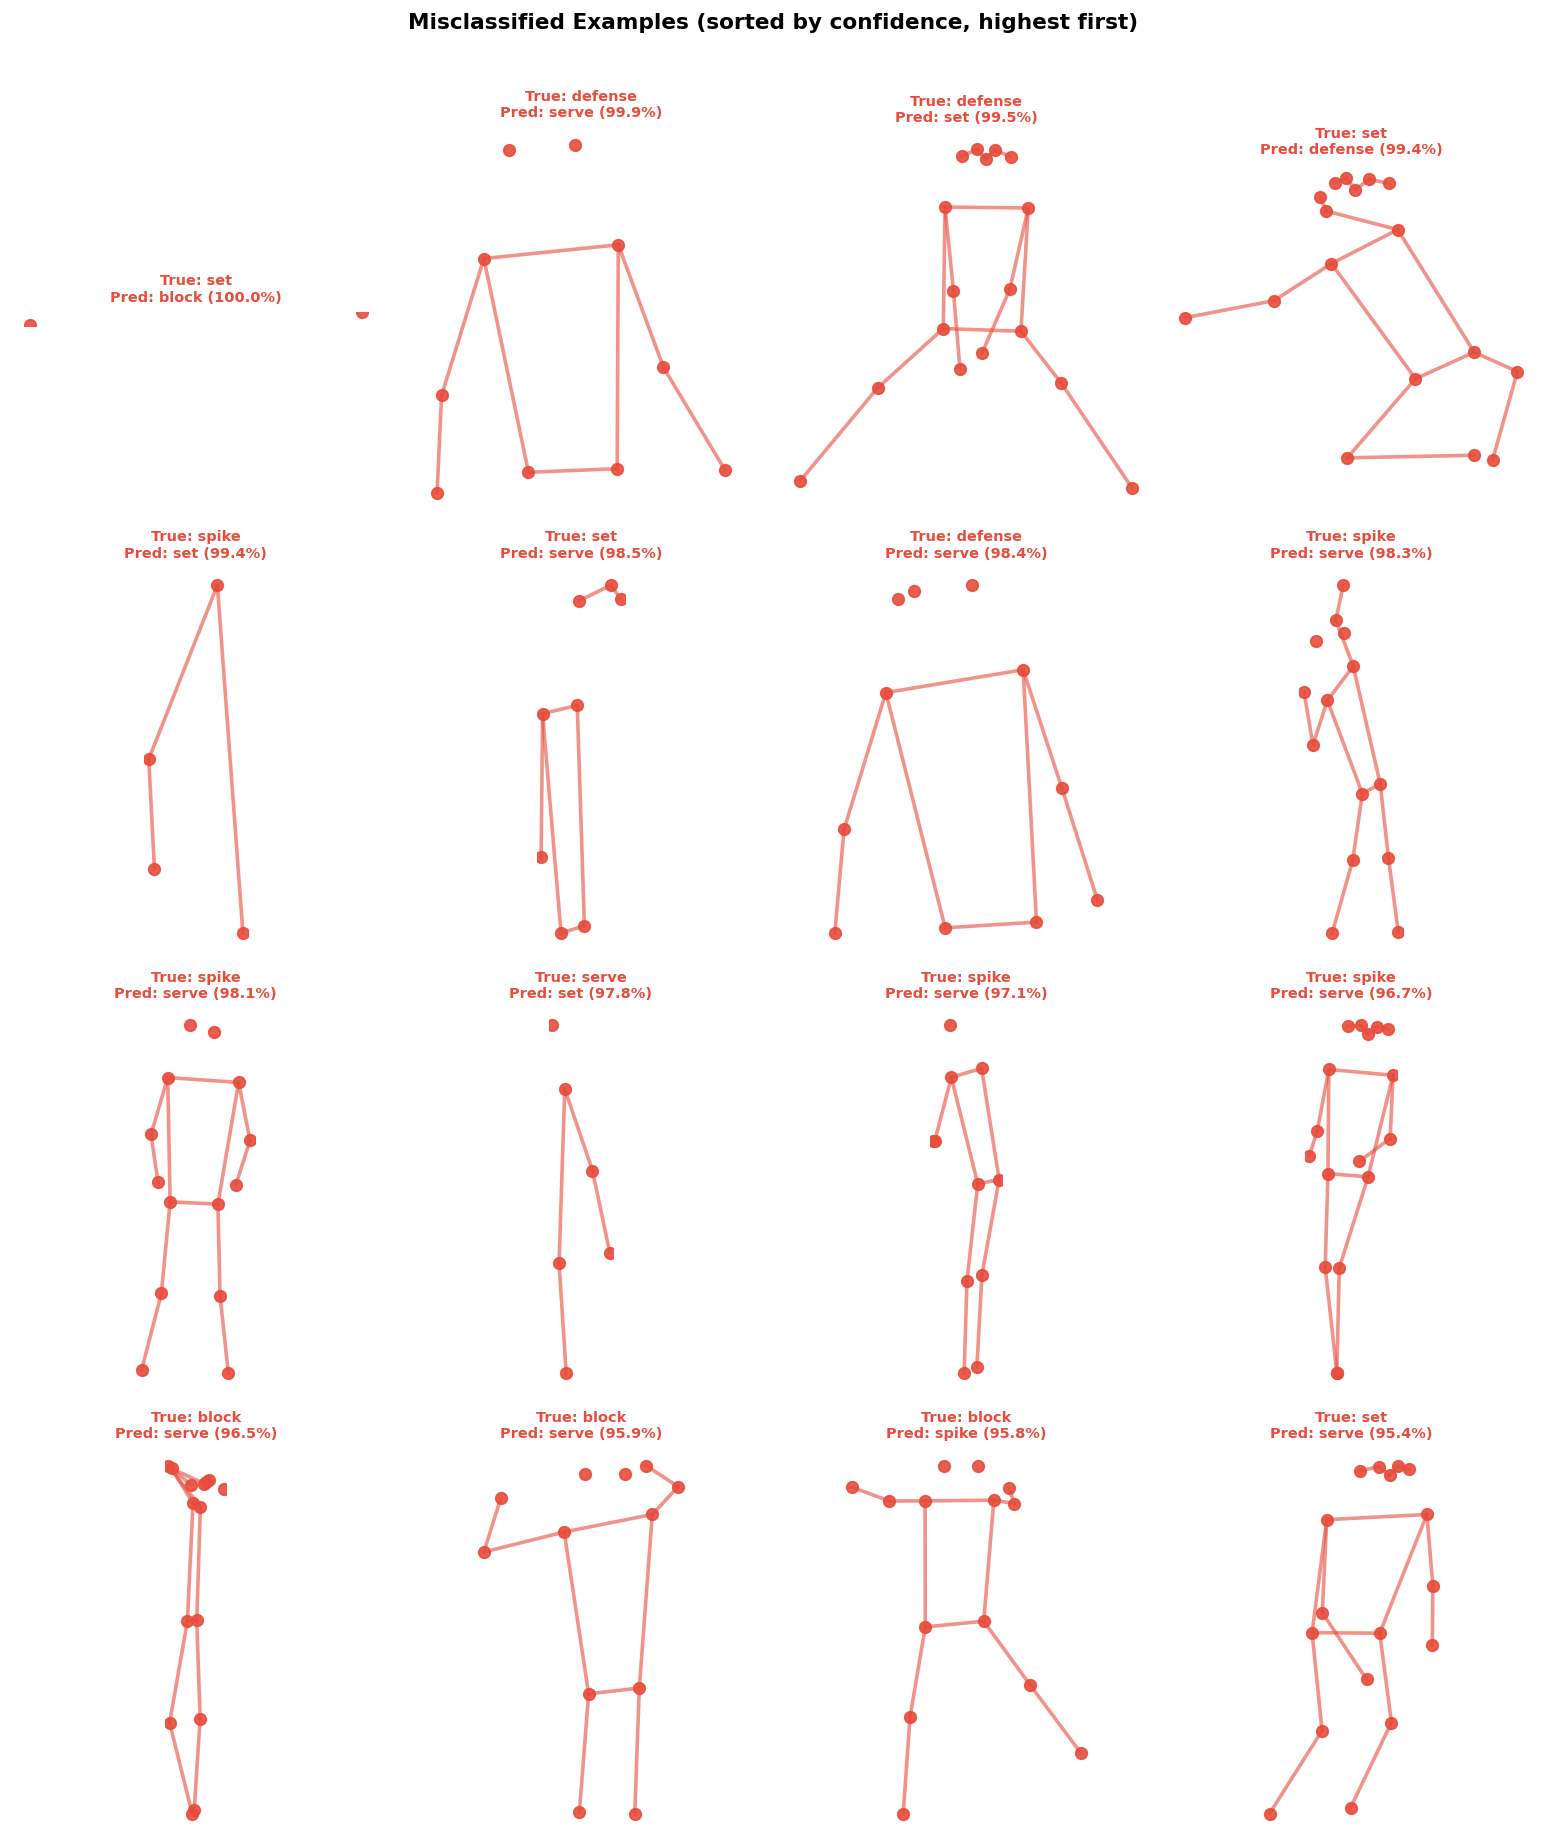

Saved → misclassified.png


In [11]:
cols = 4
rows = (len(display_idx) + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(cols * 3, rows * 3.5))
axes = axes.flatten()

for ax, idx in zip(axes, display_idx):
    kp_raw = load_raw_kp(all_paths[idx])
    conf   = all_probs[idx][all_preds[idx]]
    title  = (
        f'True: {CLASS_NAMES[all_labels[idx]]}\n'
        f'Pred: {CLASS_NAMES[all_preds[idx]]} ({conf*100:.1f}%)'
    )
    draw_skeleton_ax(ax, kp_raw, title, '#e74c3c')

for ax in axes[len(display_idx):]:
    ax.axis('off')

plt.suptitle('Misclassified Examples (sorted by confidence, highest first)',
             fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('visuals/misclassified.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → misclassified.png')

## Confidence Distribution

Per-class histogram of max softmax score, split by correct vs wrong predictions.

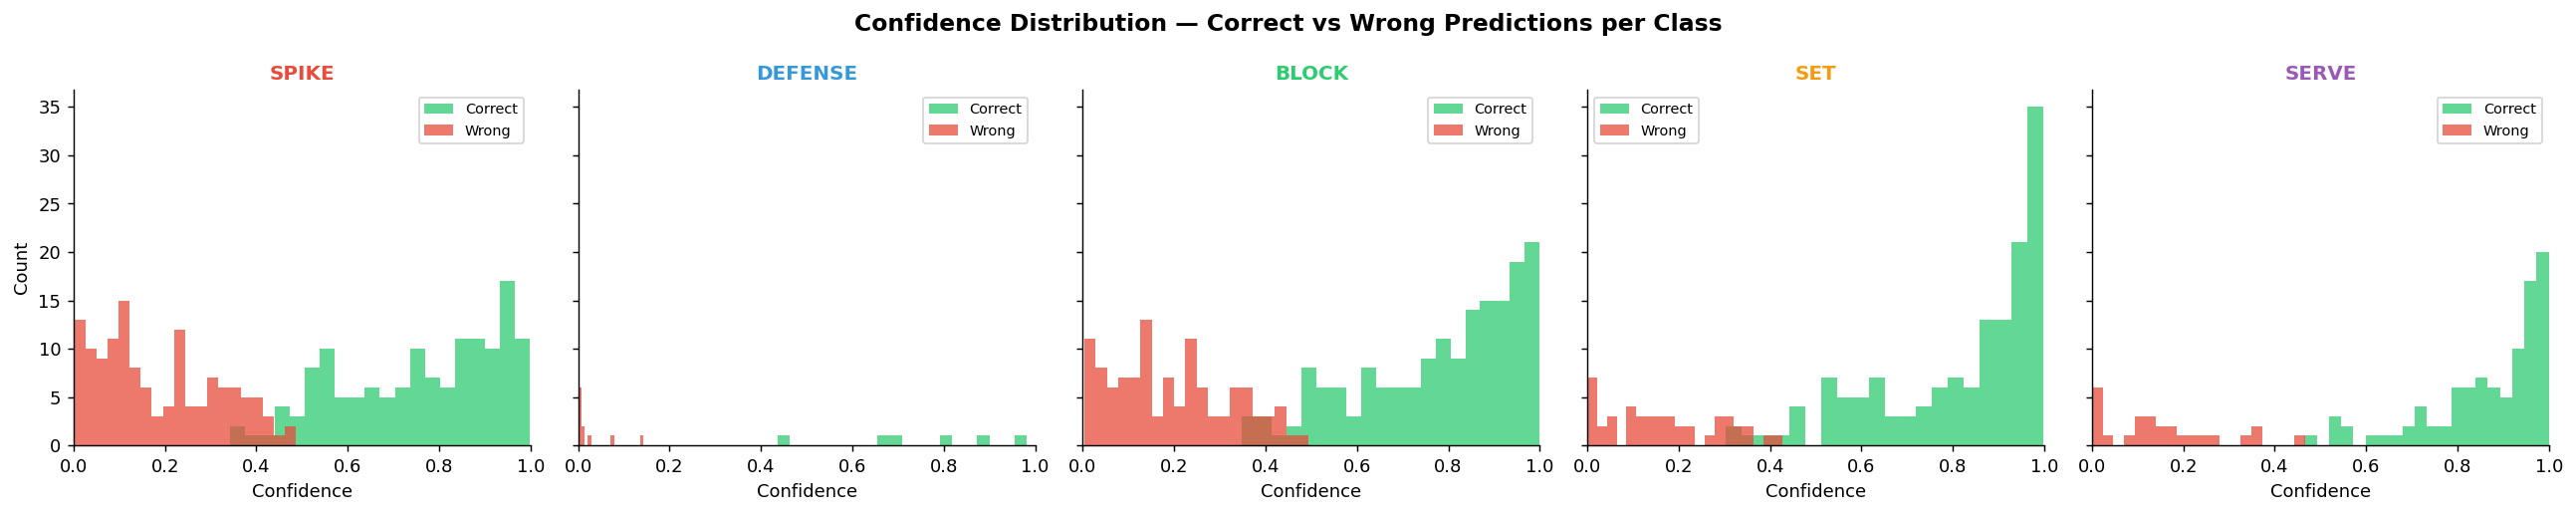

Saved → confidence_dist.png


In [12]:
fig, axes = plt.subplots(1, len(CLASS_NAMES), figsize=(20, 4), sharey=True)

for cls_idx, (cls_name, ax) in enumerate(zip(CLASS_NAMES, axes)):
    mask = all_labels == cls_idx
    if mask.sum() == 0:
        ax.set_title(f'{cls_name}\n(no samples)')
        continue

    correct_conf   = all_probs[mask & (all_preds == all_labels), cls_idx]
    incorrect_conf = all_probs[mask & (all_preds != all_labels), cls_idx]

    ax.hist(correct_conf,   bins=20, alpha=0.75, color='#2ecc71', label='Correct')
    ax.hist(incorrect_conf, bins=20, alpha=0.75, color='#e74c3c', label='Wrong')
    ax.set_title(cls_name.upper(), fontsize=11, fontweight='bold',
                 color=CLASS_COLORS[cls_idx])
    ax.set_xlabel('Confidence')
    ax.set_xlim(0, 1)
    if cls_idx == 0:
        ax.set_ylabel('Count')
    ax.legend(fontsize=8)

fig.suptitle('Confidence Distribution — Correct vs Wrong Predictions per Class',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('visuals/confidence_dist.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → confidence_dist.png')

## Mean Skeleton Visualisation

Averages the hip-centred, torso-scaled XY keypoint positions across all samples in each class. Shows what the model's training data "looks like" on average per action.

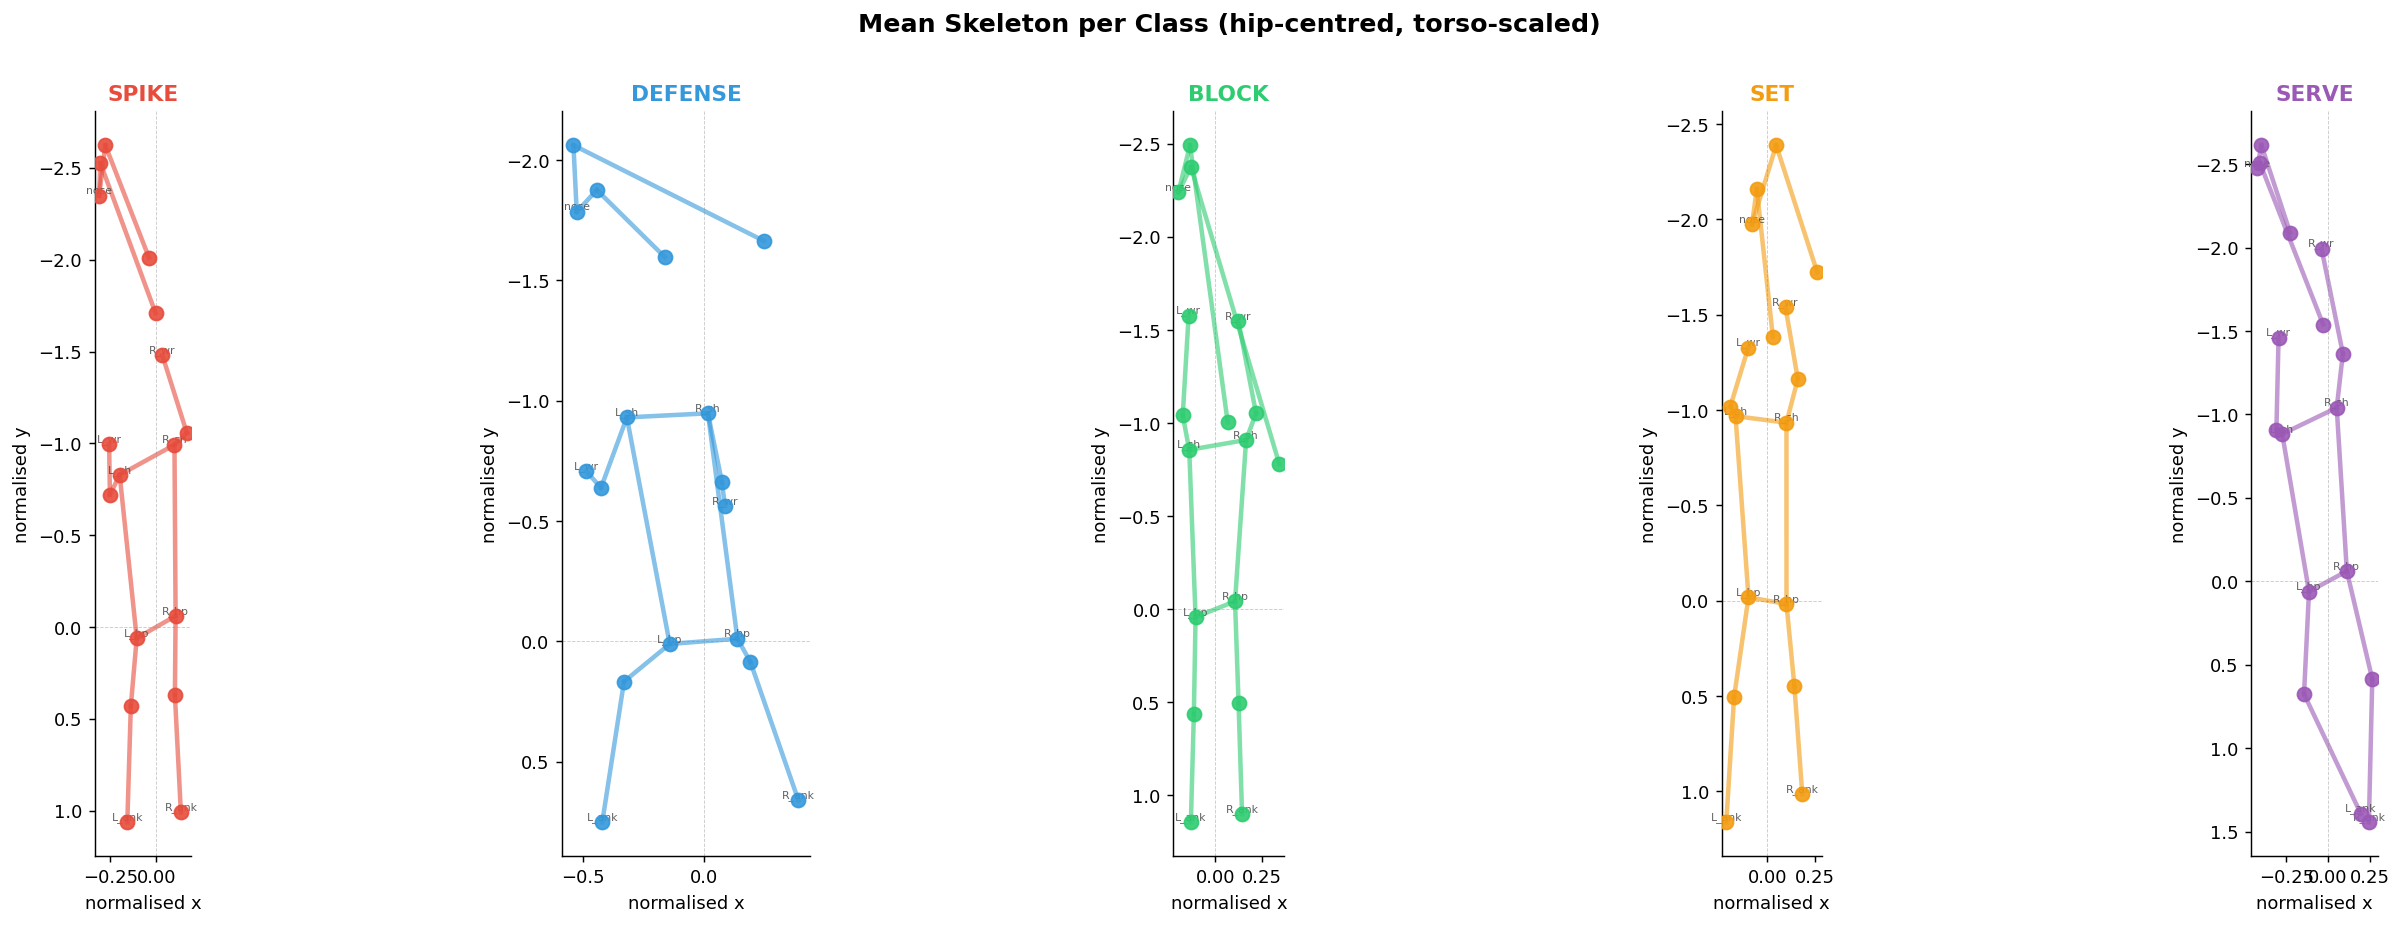

Saved → mean_skeletons.png


In [13]:
def draw_mean_skeleton(ax, xy_mean, title, color):
    """Draw mean COCO skeleton (normalised coords) on ax."""
    for (i, j) in SKELETON:
        xs = [xy_mean[i, 0], xy_mean[j, 0]]
        ys = [xy_mean[i, 1], xy_mean[j, 1]]
        if xs == [0, 0] and ys == [0, 0]:
            continue
        ax.plot(xs, ys, '-', color=color, lw=2.5, alpha=0.6)

    ax.scatter(xy_mean[:, 0], xy_mean[:, 1], s=60, c=color, zorder=5, alpha=0.9)

    for kp_idx, name in [
        (0, 'nose'), (5, 'L_sh'), (6, 'R_sh'),
        (9, 'L_wr'), (10, 'R_wr'),
        (11, 'L_hp'), (12, 'R_hp'),
        (15, 'L_ank'), (16, 'R_ank'),
    ]:
        ax.annotate(name, (xy_mean[kp_idx, 0], xy_mean[kp_idx, 1]),
                    fontsize=6, ha='center', va='bottom', color='#444', alpha=0.85)

    ax.set_title(title, fontweight='bold', color=color, fontsize=12)
    ax.set_aspect('equal')
    ax.invert_yaxis()
    ax.axhline(0, color='grey', lw=0.5, ls='--', alpha=0.4)
    ax.axvline(0, color='grey', lw=0.5, ls='--', alpha=0.4)
    ax.set_xlabel('normalised x')
    ax.set_ylabel('normalised y')


# Build per-class mean XY from the normalised feature vectors (first 34 dims = 17 joints × xy)
class_xy_mean = {}
for cls_idx, cls_name in IDX_TO_CLASS.items():
    mask = all_labels == cls_idx
    xy   = all_feats[mask, :34].reshape(-1, 17, 2)
    class_xy_mean[cls_name] = xy.mean(axis=0)

fig, axes = plt.subplots(1, len(CLASS_NAMES), figsize=(22, 7))
for cls_idx, (cls_name, color) in enumerate(zip(CLASS_NAMES, CLASS_COLORS)):
    draw_mean_skeleton(axes[cls_idx], class_xy_mean[cls_name], cls_name.upper(), color)

fig.suptitle('Mean Skeleton per Class (hip-centred, torso-scaled)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('visuals/mean_skeletons.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → mean_skeletons.png')